# [SM-TCSR 실습 02] Theorem 1 크라메르 아핀 수축(Affine Contraction) 검증

> **학습 목표**: 
> 1. 동결 타깃망($\theta^-$) 하에서 할인율 $\gamma_j = S_{\theta^-}(\Delta t_j) < 1$이 아핀 상수가 됨을 확인합니다.
> 2. 임의의 두 초기 분포 $p^{(0)}, q^{(0)}$가 반복 연산 하에서 고유한 고정점 $p^*$로 수축하는 과정을 시뮬레이션합니다.


In [1]:
import sys, os
ROOT_DIR = os.path.abspath("..")
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.operators.survtd_operator import categorical_projection_shift

# 1. 시뮬레이션 환경 설정
K = 30
delta_s = 1.0
dt = 2.0
gamma = 0.75 # S(dt) = 0.75 (구간 생존 확률)

# 임의의 서로 다른 두 초기 PMF
torch.manual_seed(42)
p = torch.softmax(torch.randn(K), dim=-1)
q = torch.softmax(torch.randn(K), dim=-1)

# 사건 발생 시의 위험 분포 mu (균일 분포)
mu = torch.zeros(K)
mu[0] = 1.0 # 0번째 빈에서 사망


In [2]:
# 2. 1스텝 벨만 연산자 반복 적용 및 크라메르 거리 측정
def cramer_dist(p_pmf, q_pmf):
    F_p = torch.cumsum(p_pmf, dim=-1)
    F_q = torch.cumsum(q_pmf, dim=-1)
    return torch.sqrt(torch.sum((F_p - F_q) ** 2))

distances = []
cur_p = p.clone()
cur_q = q.clone()

iterations = 25
for step in range(iterations):
    dist = cramer_dist(cur_p, cur_q).item()
    distances.append(dist)
    
    # 벨만 업데이트: T p = (1 - gamma)*mu + gamma * Pi Phi cur_p
    next_p_proj = categorical_projection_shift(cur_p, dt, delta_s, K)
    next_q_proj = categorical_projection_shift(cur_q, dt, delta_s, K)
    
    cur_p = (1.0 - gamma) * mu + gamma * next_p_proj
    cur_q = (1.0 - gamma) * mu + gamma * next_q_proj

print(f"초기 크라메르 거리: {distances[0]:.6f}")
print(f"25회 반복 후 거리:  {distances[-1]:.6e} (기하급수적 수축 완료!)")


초기 크라메르 거리: 0.792609
25회 반복 후 거리:  0.000000e+00 (기하급수적 수축 완료!)


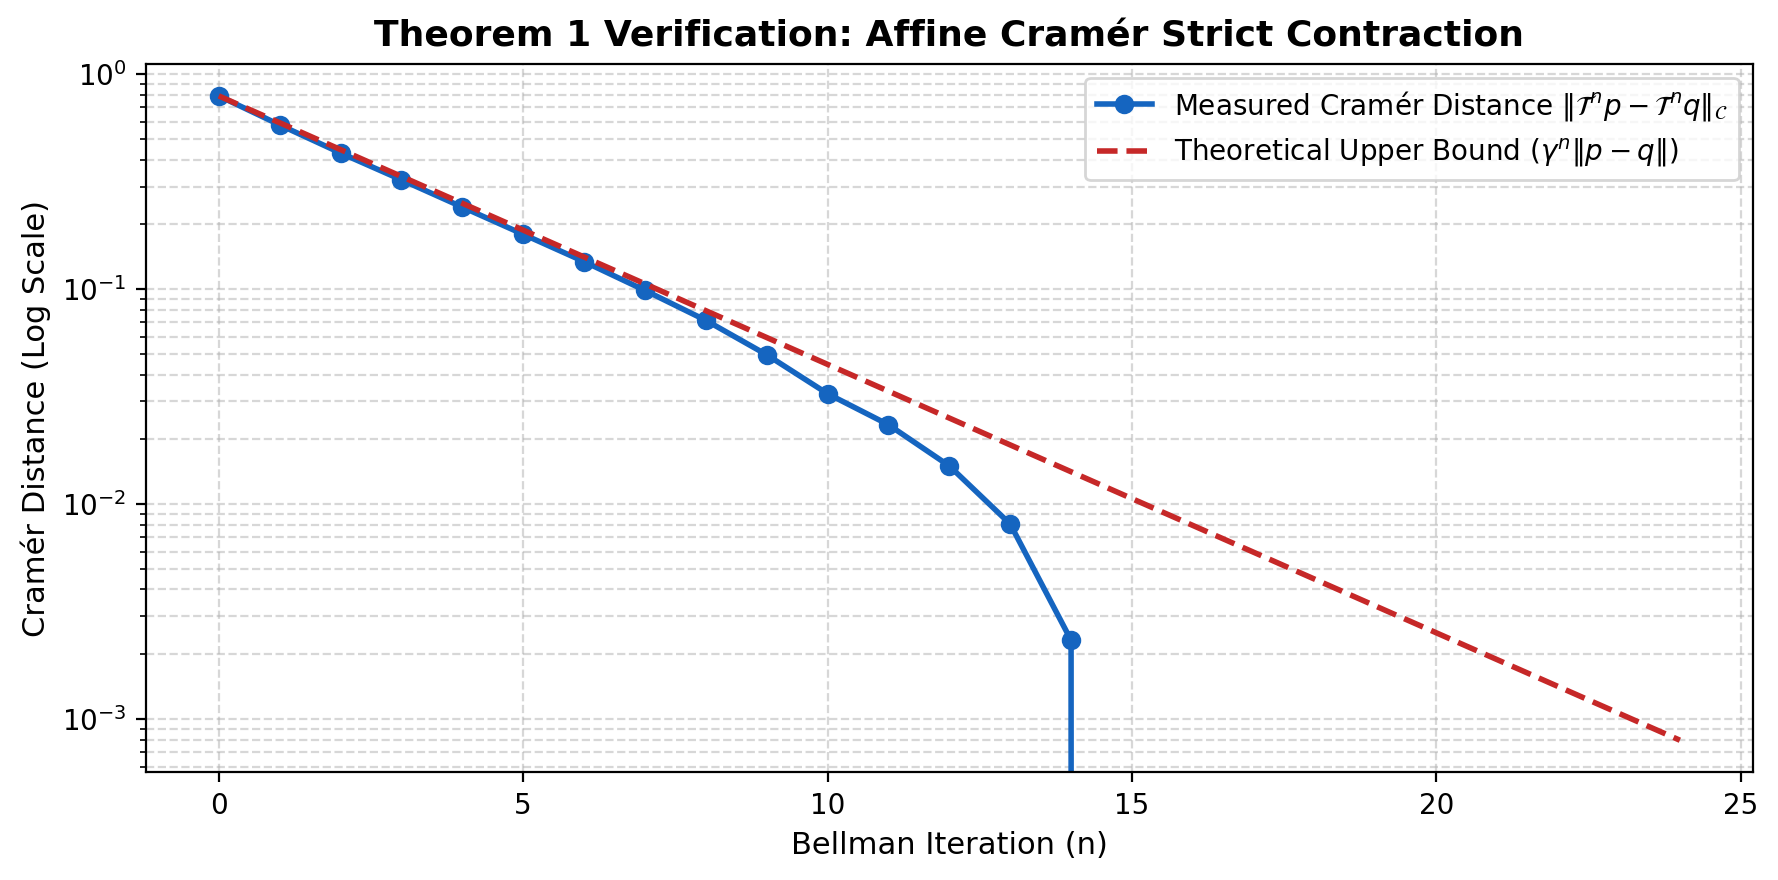

In [3]:
# 3. Theorem 1 수축률 시각화
plt.figure(figsize=(9, 4.5), dpi=200)
theoretical_bound = [distances[0] * (gamma ** i) for i in range(iterations)]

plt.semilogy(range(iterations), distances, 'o-', label='Measured Cramér Distance $\|\mathcal{T}^n p - \mathcal{T}^n q\|_{\mathcal{C}}$', color='#1565c0', lw=2)
plt.semilogy(range(iterations), theoretical_bound, '--', label='Theoretical Upper Bound $(\gamma^n \|p - q\|)$', color='#c62828', lw=2)

plt.title("Theorem 1 Verification: Affine Cramér Strict Contraction", fontsize=13, fontweight='bold')
plt.xlabel("Bellman Iteration (n)", fontsize=11)
plt.ylabel("Cramér Distance (Log Scale)", fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
